In [1]:
import sys
import tensorflow as tf
print(f"TensorFlow ver is {tf.__version__}")
print(f"PYTHON ver is {sys.version}")
print("GPU is","available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")

TensorFlow ver is 2.10.0
PYTHON ver is 3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]
GPU is available


In [2]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
#tf.compat.v1.disable_eager_execution()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import pandas as pd
from tensorflow import keras
#from tensorflow.keras import laters
import PIL
import PIL.Image
#import tensorflow_datasets as tfds
from PIL import Image
import cv2
%matplotlib inline
import pathlib
import sys
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Input, Dense, BatchNormalization, ReLU, Add, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import joblib

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
#tf.debugging.set_log_device_placement(True)     #계산시 어떤 장치로 계산하는지 표시하라는 명령어

In [3]:
# ============================================================
# 1) Load RAW CSV (정규화 전)
# ============================================================
directory = "database/"
raw_csv = "cmall_remove_duplicate_m_all.csv"   # <-- 정규화 전 파일명으로 바꾸세요
df = pd.read_csv(os.path.join(directory, raw_csv))

In [4]:
# ============================================================
# 2) Define input columns (원 코드의 stack 순서 그대로 유지)
#    ※ 컬럼명은 raw csv에도 동일해야 합니다.
# ============================================================
X_COLS = [
    "RP_roller_p1", "RP_roller_p2", "RP_sep_rpm", "RP_sep_fan_damper", "RP_sep_BF_damper", "mill_BF_damper", "mill_sep_rpm", "mill_sep_fan_damper", "grind_aid",
    "RP_spac", "RP_skew", "RP_roller_energy1", "RP_roller_energy2", "RP_roller_vib", "RP_BE_energy1", "RP_BE_energy2",
    "RP_sep_BF_pressure", "dosing_BE_energy", "mill_feed_c", "mill_feed_cir", "mill_energy", "mill_in_temp",
    "mill_out_temp", "mill_BE_energy", "mill_out_gas_temp", "mill_out_mater_temp", "mill_BF_pressure",
    "mill_sep_BF_pressure", "mill_sep_BF_fan_damper", "final_BE_1", "final_BE_2", "final_mater_temp",
    "feed_clinker", "feed_gypsum", "feed_slag", "feed_FA", "feed_total", "blaine_prev"
]
Y_COL = "blaine"

assert len(X_COLS) == 38, f"X_COLS length must be 38, got {len(X_COLS)}"

# 결측 제거 (최소한)
df = df.dropna(subset=X_COLS + [Y_COL]).reset_index(drop=True)

In [5]:
# ============================================================
# 3) Build raw X, y arrays
# ============================================================
X_raw = df[X_COLS].to_numpy(dtype=np.float32)   # (N,38)
y_raw = df[[Y_COL]].to_numpy(dtype=np.float32)  # (N,1)

print("X_raw shape:", X_raw.shape)
print("y_raw shape:", y_raw.shape)


# ============================================================
# 4) Split first, then fit scalers on TRAIN only (중요)
# ============================================================
train_x_raw, temp_x_raw, train_y_raw, temp_y_raw = train_test_split(
    X_raw, y_raw, test_size=0.30, random_state=42
)
val_x_raw, test_x_raw, val_y_raw, test_y_raw = train_test_split(
    temp_x_raw, temp_y_raw, test_size=0.50, random_state=42
)

print("Split shapes:",
      "train", train_x_raw.shape, train_y_raw.shape,
      "| val", val_x_raw.shape, val_y_raw.shape,
      "| test", test_x_raw.shape, test_y_raw.shape)

X_raw shape: (60572, 38)
y_raw shape: (60572, 1)
Split shapes: train (42400, 38) (42400, 1) | val (9086, 38) (9086, 1) | test (9086, 38) (9086, 1)


In [6]:
# ============================================================
# 5) MinMax normalization (0~1) inside code
# ============================================================
x_scaler = MinMaxScaler(feature_range=(0.0, 1.0))
y_scaler = MinMaxScaler(feature_range=(0.0, 1.0))

x_scaler.fit(X_raw)   # 전체 데이터로 fit
y_scaler.fit(y_raw)

# 2) blaine / blaine_prev 컬럼 인덱스 찾기
blaine_prev_idx = X_COLS.index("blaine_prev")

# 3) 강제 min/max 지정
CUSTOM_MIN = 3030
CUSTOM_MAX = 5500

for idx in [blaine_prev_idx]:     #for idx in [blaine_idx, blaine_prev_idx]:
    x_scaler.data_min_[idx] = CUSTOM_MIN
    x_scaler.data_max_[idx] = CUSTOM_MAX
    x_scaler.data_range_[idx] = CUSTOM_MAX - CUSTOM_MIN
    x_scaler.scale_[idx] = 1.0 / (CUSTOM_MAX - CUSTOM_MIN)
    x_scaler.min_[idx] = -CUSTOM_MIN / (CUSTOM_MAX - CUSTOM_MIN)

# 2) blaine / blaine_prev 컬럼 인덱스 찾기
blaine_idx = Y_COL.index("blaine")

# 3) 강제 min/max 지정
CUSTOM_MIN = 3030
CUSTOM_MAX = 5500

for idx in [blaine_idx]:     #for idx in [blaine_idx, blaine_prev_idx]:
    y_scaler.data_min_[idx] = CUSTOM_MIN
    y_scaler.data_max_[idx] = CUSTOM_MAX
    y_scaler.data_range_[idx] = CUSTOM_MAX - CUSTOM_MIN
    y_scaler.scale_[idx] = 1.0 / (CUSTOM_MAX - CUSTOM_MIN)
    y_scaler.min_[idx] = -CUSTOM_MIN / (CUSTOM_MAX - CUSTOM_MIN)

print("Custom scaling applied to residue columns")

train_x = x_scaler.transform(train_x_raw).astype(np.float32)
val_x   = x_scaler.transform(val_x_raw).astype(np.float32)
test_x  = x_scaler.transform(test_x_raw).astype(np.float32)

train_y = y_scaler.transform(train_y_raw).astype(np.float32)
val_y   = y_scaler.transform(val_y_raw).astype(np.float32)
test_y  = y_scaler.transform(test_y_raw).astype(np.float32)

# 스케일러 저장 (제어추천모델/실시간 추론에서 동일 사용)
joblib.dump(x_scaler, "quality_x_scaler_38.pkl")
joblib.dump(y_scaler, "quality_y_scaler_1.pkl")

print("Saved scalers: quality_x_scaler_38.pkl, quality_y_scaler_1.pkl")

Custom scaling applied to residue columns
Saved scalers: quality_x_scaler_38.pkl, quality_y_scaler_1.pkl


# Parametric Study
    # number of layers : 7
    # node shapes : 128, 1024, 2048, 2048, 1024, 64, 8
    # mini-batch size : 512
    # dropout shapes : 0.1,  0.2,0.3, 0.2, 0.2, 0.2, 0.0
    # actication func : swish

In [ ]:
# 모델 정의
def build_model(input_shape):
    model = Sequential([
        Dense(128, activation='swish', kernel_initializer='glorot_uniform', input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.1),  # 20% Dropout

        Dense(1024, activation='swish', kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(2048, activation='swish', kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        Dropout(0.3),  # 깊은 레이어에서는 30%로 증가

        Dense(2048, activation='swish', kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(1024, activation='swish', kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(64, activation='swish', kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(8, activation='swish', kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        Dropout(0.0),  # 얕은 레이어에서는 Dropout을 낮게

        Dense(1)  # 출력 레이어
    ])
    return model

# 모델 생성 및 컴파일
input_shape = (38,)
model = build_model(input_shape)
huber_loss = tf.keras.losses.Huber(delta=1.0)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss=huber_loss)

# ModelCheckpoint 콜백: 최적의 Epoch 모델 저장
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model_blaine.h5',        # 최적 모델 저장 경로                              # 저장 파일 이름 설정
    monitor='val_loss',     # 검증 손실 기준
    save_best_only=True,    # 가장 낮은 val_loss 모델만 저장
    save_weights_only=False, # 모델 전체 저장 (구조+가중치+옵티마이저 상태)
    mode='min',             # val_loss가 작을수록 좋음
    verbose=1
)

# 조기 종료 콜백
early_stopping = EarlyStopping(monitor='val_loss', patience=300, verbose=1)

In [ ]:
# 모델 요약 출력
model.summary()

In [ ]:
# 모델 학습
history = model.fit(
    train_x, train_y,
    epochs=1000,
    batch_size=1024,
    validation_data=(val_x, val_y),
    callbacks=[early_stopping, checkpoint]  # 콜백에 ModelCheckpoint 추가
)

# 최적의 모델 불러오기
best_model = tf.keras.models.load_model('best_model_blaine.h5')                     # 저장 파일 이름 설정

# 모델 평가
test_loss = best_model.evaluate(test_x, test_y)
print(f'Test Loss (Best Model): {test_loss}')

# 학습 결과 시각화
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
#plt.ylim(0.0, 0.002)   #y축 범위 설정
plt.legend()
plt.show()

In [ ]:
# 학습 결과 시각화
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0.0, 0.002)   #y축 범위 설정
plt.legend()
plt.show()

#학습 후 결과 확인

In [ ]:
print(test_x.shape)
print(test_y.shape)
print(test_x[1])
print(test_y[0])

In [9]:
# 최적의 모델 불러오기
best_model = tf.keras.models.load_model('best_model_blaine.h5')                     # 저장 파일 이름 설정

# ============================================================
# 9) Sample prediction + inverse transform to real blaine
# ============================================================
idx = min(1, test_x.shape[0]-1)

sample_x = test_x[idx].reshape(1, -1)
sample_y = test_y[idx].reshape(1, -1)

pred_y = best_model.predict(sample_x, verbose=0)

actual_blaine = y_scaler.inverse_transform(sample_y)[0, 0]
pred_blaine   = y_scaler.inverse_transform(pred_y)[0, 0]

print(f"Actual blaine   : {actual_blaine:.2f}")
print(f"Predicted blaine: {pred_blaine:.2f}")
print(f"Abs error       : {abs(actual_blaine - pred_blaine):.2f}")

Actual blaine   : 3530.00
Predicted blaine: 3549.51
Abs error       : 19.51


In [10]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------
# 0) (중요) np.matrix 방지: ndarray로 강제 변환
# ------------------------------------
test_x_arr = np.asarray(test_x)
test_y_arr = np.asarray(test_y)

# ------------------------------------
# 1) test set 예측 (정규화된 y 스케일)
# ------------------------------------
y_pred_norm = np.asarray(best_model.predict(test_x_arr))  # (N,1) normalized
y_true_norm = test_y_arr                                  # (N,1) normalized

# ------------------------------------
# 2) 정규화값 -> 실제 blaine로 역변환
#    - "코드 내 정규화"로 바꿨다면 inverse는 scaler_y를 써야 합니다.
# ------------------------------------
# [CASE A] 위에서 제시한 코드처럼 MinMaxScaler(y_scaler)를 사용한 경우 (권장)
#         y_scaler는 학습 코드에서 만든 scaler 객체 그대로 가져오거나,
#         저장해둔 pkl을 로드해서 사용하세요.
#
# 예)
# import joblib
# y_scaler = joblib.load("quality_y_scaler_1.pkl")

y_pred_real = y_scaler.inverse_transform(y_pred_norm)
y_true_real = y_scaler.inverse_transform(y_true_norm)
# sample-wise absolute error (real scale)
abs_err = np.abs(y_true_real - y_pred_real)   # (N,1) or (N,)

# ------------------------------------
# 3) MAE / RMSE / R2 계산
# ------------------------------------
mae  = mean_absolute_error(y_true_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
r2   = r2_score(y_true_real, y_pred_real)

# min / max error
min_err = float(np.min(abs_err))
max_err = float(np.max(abs_err))

print(f"Test MAE  (residue): {mae:.2f}")
print(f"Test RMSE (residue): {rmse:.2f}")
print(f"Test R²           : {r2:.4f}")
print(f"Test Min |error|  : {min_err:.2f}")
print(f"Test Max |error|  : {max_err:.2f}")


284/284 [==============================] - 2s 5ms/step
Test MAE  (residue): 35.63
Test RMSE (residue): 54.57
Test R²           : 0.7883
Test Min |error|  : 0.00
Test Max |error|  : 444.10


# Confusion matrix 계산 (Blaine)

284/284 [==============================] - 1s 4ms/step


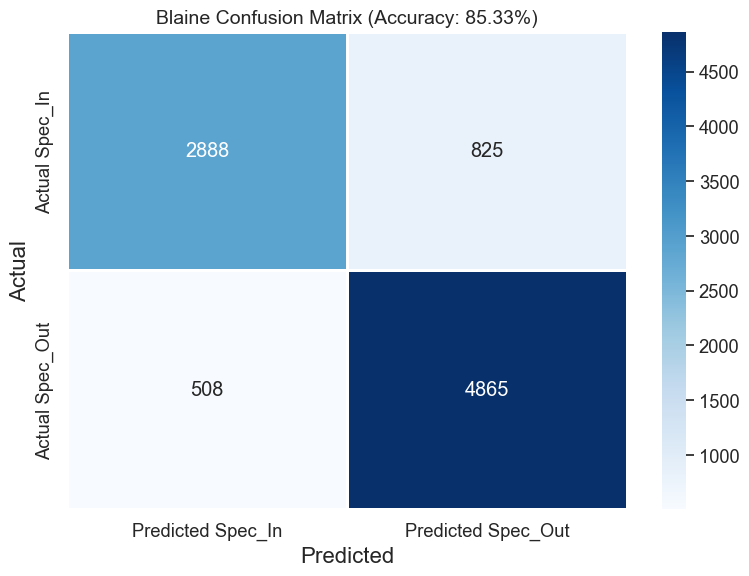

In [11]:
# ------------------------------------
# 0) ndarray 보장 (np.matrix 방지)
# ------------------------------------
test_x_arr = np.asarray(test_x)
test_y_arr = np.asarray(test_y)

# ------------------------------------
# 1) 정규화된 값 예측
# ------------------------------------
y_pred_norm = np.asarray(best_model.predict(test_x_arr))   # (N,1) normalized
y_true_norm = test_y_arr                                   # (N,1) normalized

# ------------------------------------
# 2) 정규화 → 실제 blaine 값으로 역변환
#    (코드 내 MinMaxScaler 방식)
# ------------------------------------
# y_scaler는 학습 단계에서 fit 후 저장한 scaler
# 예: y_scaler = joblib.load("quality_y_scaler_1.pkl")

actual_blaine = y_scaler.inverse_transform(y_true_norm)[:, 0]
predicted_blaine = y_scaler.inverse_transform(y_pred_norm)[:, 0]

# ------------------------------------
# 3) 실제값 및 예측값을 OK / NG로 변환
# ------------------------------------
def categorize_blaine(blaine_values):
    return np.array([
        "OK" if 3700 <= value <= 3900 else "NG"
        for value in blaine_values
    ])

actual_labels = categorize_blaine(actual_blaine)
predicted_labels = categorize_blaine(predicted_blaine)

# ------------------------------------
# 4) Confusion Matrix 및 Accuracy 계산
# ------------------------------------
conf_matrix = confusion_matrix(
    actual_labels,
    predicted_labels,
    labels=["OK", "NG"]
)

accuracy = accuracy_score(actual_labels, predicted_labels)

# DataFrame 변환 (시각화용)
df_conf_matrix = pd.DataFrame(
    conf_matrix,
    index=["Actual Spec_In", "Actual Spec_Out"],
    columns=["Predicted Spec_In", "Predicted Spec_Out"]
)

# ------------------------------------
# 5) Confusion Matrix 시각화
# ------------------------------------
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)

ax = sns.heatmap(
    df_conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="white"
)

plt.title(
    f"Blaine Confusion Matrix (Accuracy: {accuracy * 100:.2f}%)",
    fontsize=14
)
plt.xlabel("Predicted", fontsize=16)
plt.ylabel("Actual", fontsize=16)

plt.tight_layout()
plt.show()